# PYORPS Tutorial: Automated Underground Cable Routing for Distribution Grid Planning

**OSMSES 2026 &mdash; 4th International Workshop on Open Source Modelling and Simulation of Energy Systems**
*March 23&ndash;25, 2026 &mdash; Karlsruhe, Germany*

**Speaker:** Martin Hofmann M.Sc.

---

## Tutorial Overview

This hands-on tutorial introduces **PYORPS** (*Python for Optimal Routes in Power Systems*), an open-source tool for automated power line routing using least-cost path analysis on high-resolution raster geodata.

**Duration:** 1.5 hours

### What You Will Learn

| # | Topic | Time |
|---|-------|------|
| 1 | PYORPS Fundamentals &mdash; raster costs, neighborhoods, pathfinding | ~15 min |
| 2 | **Creating a Cost Raster** &mdash; from open geodata (WFS) with multiple layers | ~20 min |
| 3 | **Case Study 1** &mdash; PCC optimization for a utility-scale PV system | ~25 min |
| 4 | **Case Study 2** &mdash; Automated grid extension with Delaunay triangulation & ring opening | ~35 min |
| 5 | Summary & next steps | ~10 min |

### Prerequisites
- Basic knowledge of power distribution systems
- Python programming (intermediate level)
- `pyorps`, `pandapower`, `scipy`, `geopandas`, `matplotlib` installed

## 0. Setup & Installation

Install PYORPS with all optional dependencies (includes pandapower, geopandas, etc.):

```bash
pip install pyorps[full]
```

If you only need the core routing functionality:
```bash
pip install pyorps
```

In [1]:
# Verify installation
import pyorps
print(f"PYORPS version: {pyorps.__version__}")

PYORPS version: 0.3.1


In [2]:
# Standard imports used throughout the tutorial
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm, PowerNorm
from shapely.geometry import Point, LineString, MultiPoint
from scipy.spatial import Delaunay

import pandapower as pp
from pandapower.topology import create_nxgraph
from networkx import cycle_basis

from pyorps import (PathFinder, PathCollection, initialize_geo_dataset,
                    GeoRasterizer, CostAssumptions, detect_feature_columns)
import rasterio
from rasterio.plot import show as rshow


def plot_cost_raster(ax, data, title=None, alpha=0.7):
    """Plot cost raster in greyscale (dark = low cost, white = forbidden)."""
    display = np.where(data >= 65535, np.nan, data.astype(float))
    ax.imshow(display, cmap='gray', norm=PowerNorm(gamma=0.5, vmin=0, vmax=500),
              origin='upper', interpolation='nearest', alpha=alpha)
    if title:
        ax.set_title(title, fontsize=13)

---
# Introduction: How PYORPS Works

PYORPS converts the routing problem into a **graph-based shortest-path problem**:

1. **Raster input** &mdash; Each pixel represents a terrain type with an associated construction cost (EUR/m)
2. **Graph creation** &mdash; Pixels become nodes; edges connect neighboring pixels weighted by cost &times; distance
3. **Shortest path** &mdash; Dijkstra's algorithm finds the minimum-cost route
4. **Result** &mdash; A georeferenced path with length, cost breakdown, and exportable geometry

### Cost Values

| Value | Meaning |
|-------|---------|
| 0 | Free passage (e.g., existing duct) |
| 90&ndash;500 | Typical construction costs in EUR/m |
| 65535 | **Forbidden / impassable** (residential areas, protected zones) |

Values are stored as `uint16` (0&ndash;65535).

## Minimal Example

Three lines are enough: create a `PathFinder`, call `find_route()`, visualize.

Path(id=0, source=(472000, 5593400), target=(472800, 5594000), length_m=1192.43, cost=133578.05)

Length: 1192 m | Cost: 133578 EUR | Detour: 1.19x


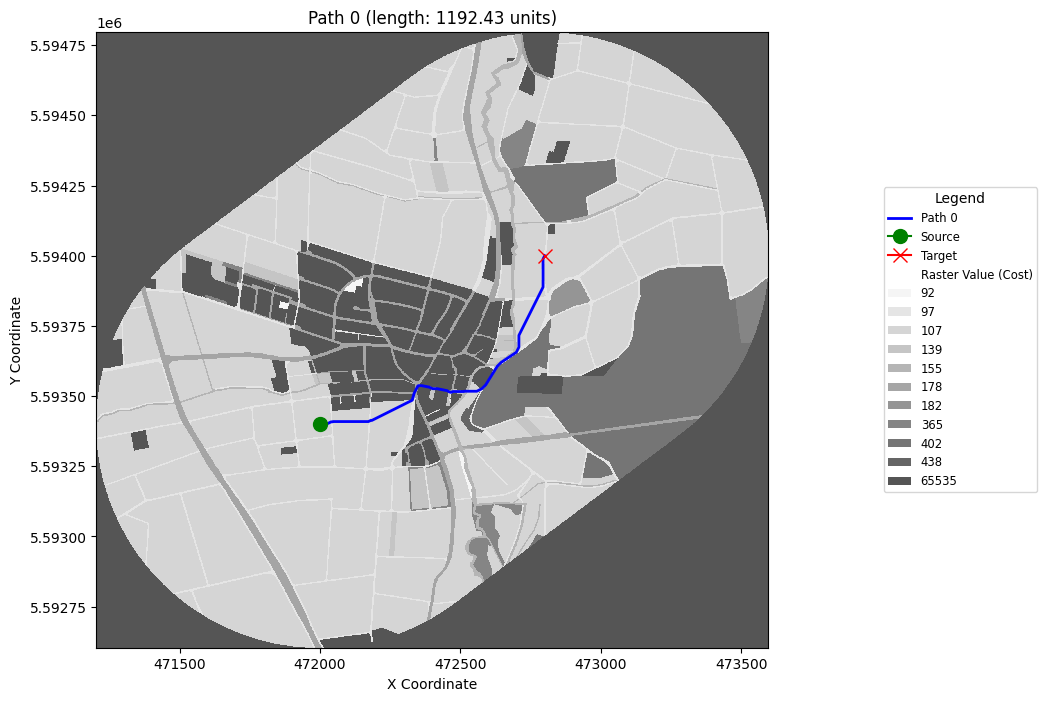

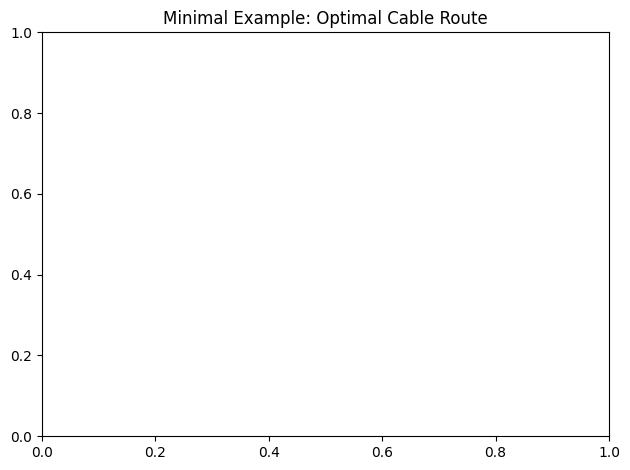

In [3]:
source = (472000, 5593400)
target = (472800, 5594000)
raster_path = "../examples/data/raster/sample_raster.tiff"

pf = PathFinder(dataset_source=raster_path, source_coords=source,
                target_coords=target, neighborhood_str="r2")

path = pf.find_route()
print(path)
print(f"\nLength: {path.total_length:.0f} m | Cost: {path.total_cost:.0f} EUR "
      f"| Detour: {path.total_length / path.euclidean_distance:.2f}x")

pf.plot_paths()
plt.title("Minimal Example: Optimal Cable Route")
plt.tight_layout()
plt.show()

---
# Part 1: Creating a Cost Raster from Open Geodata

In practice you build your cost raster from publicly available geodata.
This part shows how &mdash; step by step:

1. **Base layer** &mdash; Land-use data from the official cadastre (ALKIS)
2. **Protection layers** &mdash; Naturschutz, Vogelschutz, Wasserschutz, Landschaftsschutz

Each layer is fetched live from an official **WFS** (Web Feature Service) provided by
the state of Baden-W&uuml;rttemberg.

## 1.1 Study Area &amp; Base Land-Use Data

We pick a **5 &times; 5&nbsp;km** window inside the MV Oberrhein region and
load **ALKIS** land-use polygons via WFS.

In [4]:
# 5 x 5 km bounding box in the MV Oberrhein area (EPSG:25832)
bbox_tutorial = (410000, 5358000, 415000, 5363000)

# WFS for Baden-Wuerttemberg ALKIS land-use data
alkis_wfs = {
    'url': r"https://owsproxy.lgl-bw.de/owsproxy/wfs/WFS_LGL-BW_ALKIS?version=2.0.0",
    'layer': "Tatsaechliche Nutzung"
}

# Load and inspect
base_dataset = initialize_geo_dataset(alkis_wfs, bbox=bbox_tutorial)
base_dataset.load_data()
print(f"Features loaded: {len(base_dataset.data):,}")

# detect_feature_columns() suggests the best column for cost categorisation
main_feature, _ = detect_feature_columns(base_dataset.data, max_features_per_column=100)
print(f"Feature column: '{main_feature}'")
print(base_dataset.data[main_feature].value_counts().head(10).to_string())

Features loaded: 1,776
Feature column: 'unterart_name'
unterart_name
Weg                                                  537
Ackerland                                            358
Wohnbaufläche                                        224
Grünland                                             174
Straßenverkehr                                       104
Graben                                                60
Garten                                                54
Gebäude- und Freifläche Land- und Forstwirtschaft     34
Gebäude- und Freifläche Industrie und Gewerbe         30
Handel und Dienstleistung                             28


## 1.2 Define Cost Assumptions

Each land-use category gets a construction cost in **EUR/m**.
The special value **65535** marks areas as **impassable** (e.g., residential zones).

In [5]:
# Cost assumptions for BW ALKIS land-use categories (EUR/m)
base_cost_assumptions = {
    main_feature: {
        # --- Forbidden areas (65535 = impassable) ---
        'Wohnbaufläche': 65535,
        'Gebäude- und Freifläche Industrie und Gewerbe': 65535,
        'Gebäude- und Freifläche Land- und Forstwirtschaft': 65535,
        'Handel und Dienstleistung': 65535,
        'Friedhof': 65535,
        'Bergbau': 65535,
        'Sumpf': 65535,
        'Flugverkehr': 65535,

        # --- Passable areas (sorted by increasing cost) ---
        'Weg': 97,
        'Graben': 120,
        'Grünland': 200,
        'Ackerland': 250,
        'Garten': 300,
        'Platz': 152,
        'Fließgewässer': 155,
        'Stehendes Gewässer': 155,
        'Straßenverkehr': 178,
        'Laubholz': 365,
        'Nadelholz': 365,
        'Laub- und Nadelholz': 365,
        'Bahnverkehr': 415,
        'Sport-, Freizeit- und Erholungsfläche': 107,
        'Heide': 92,
        'Moor': 92,
        'Unland/Vegetationslose Fläche': 92,
    }
}

## 1.3 Rasterize the Base Layer

`GeoRasterizer` converts the vector polygons into a raster where each pixel holds
the cost value of its land-use category.

Raster: (7794, 7561), 1.0 m/pixel


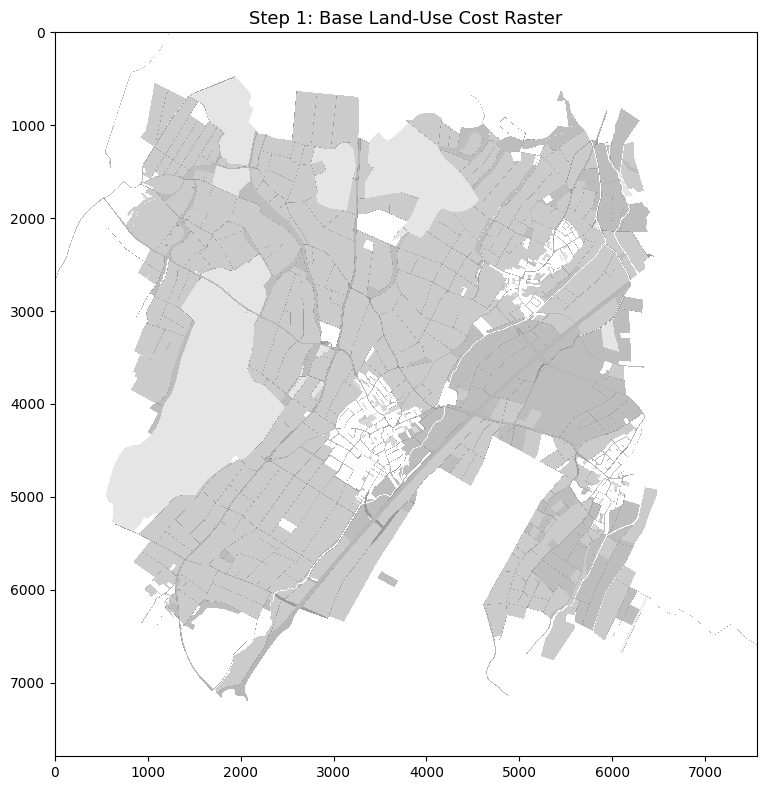

In [6]:
import os
os.makedirs("../tutorial/output", exist_ok=True)
base_raster_path = "../tutorial/output/base_cost_raster.tiff"

geo_rasterizer = GeoRasterizer(base_dataset, CostAssumptions(base_cost_assumptions))
geo_rasterizer.rasterize(save_path=base_raster_path)

with rasterio.open(base_raster_path) as src:
    base_data = src.read(1)
    print(f"Raster: {base_data.shape}, {abs(src.transform.a):.1f} m/pixel")

fig, ax = plt.subplots(figsize=(10, 8))
plot_cost_raster(ax, base_data, title="Step 1: Base Land-Use Cost Raster")
plt.tight_layout()
plt.show()

## 1.4 Define Modification Layers (Protection Zones)

Each additional dataset modifies the base raster:

| Layer | WFS source | Effect |
|-------|-----------|--------|
| Naturschutzgebiete | LUBW | Override &rarr; 65535 (forbidden) |
| Vogelschutzgebiete | LUBW | Multiply &times; 1.75 |
| Wasserschutzgebiete | LUBW | Multiply &times; 1.5 |
| Landschaftsschutzgebiete | LUBW | Multiply &times; 1.25 |

In [7]:
# LUBW base URL for WFS services
lubw = "https://rips-gdi.lubw.baden-wuerttemberg.de/arcgis/services/wfs"

# WFS request dicts
nature_wfs      = {'url': f"{lubw}/Naturschutzgebiet/MapServer/WFSServer",
                   'layer': "Naturschutzgebiet"}
bird_wfs        = {'url': f"{lubw}/Vogelschutzgebiet_SPA/MapServer/WFSServer",
                   'layer': "Vogelschutzgebiet_SPA"}
water_wfs       = {'url': f"{lubw}/Wasserschutzgebiet/MapServer/WFSServer",
                   'layer': "Wasserschutzgebiet"}
landscape_wfs   = {'url': f"{lubw}/Landschaftsschutzgebiet/MapServer/WFSServer",
                   'layer': "Landschaftsschutzgebiet"}

# Modification list: each dict is passed to geo_rasterizer.modify_raster_from_dataset()
datasets_to_modify = [
    {"input_data": nature_wfs,    "cost_assumptions": 65535, "multiply": False},
    {"input_data": bird_wfs,      "cost_assumptions": 1.75,  "multiply": True},
    {"input_data": water_wfs,     "cost_assumptions": 1.5,   "multiply": True},
    {"input_data": landscape_wfs, "cost_assumptions": 1.25,  "multiply": True},
]

for d in datasets_to_modify:
    action = "multiply" if d["multiply"] else "override"
    print(f"  {d['input_data']['layer']:30s}  ({action}, {d['cost_assumptions']})")

  Naturschutzgebiet               (override, 65535)
  Vogelschutzgebiet_SPA           (multiply, 1.75)
  Wasserschutzgebiet              (multiply, 1.5)
  Landschaftsschutzgebiet         (multiply, 1.25)


## 1.5 Apply All Layers &amp; Compare

We apply the modifications and compare the base raster against the final result.

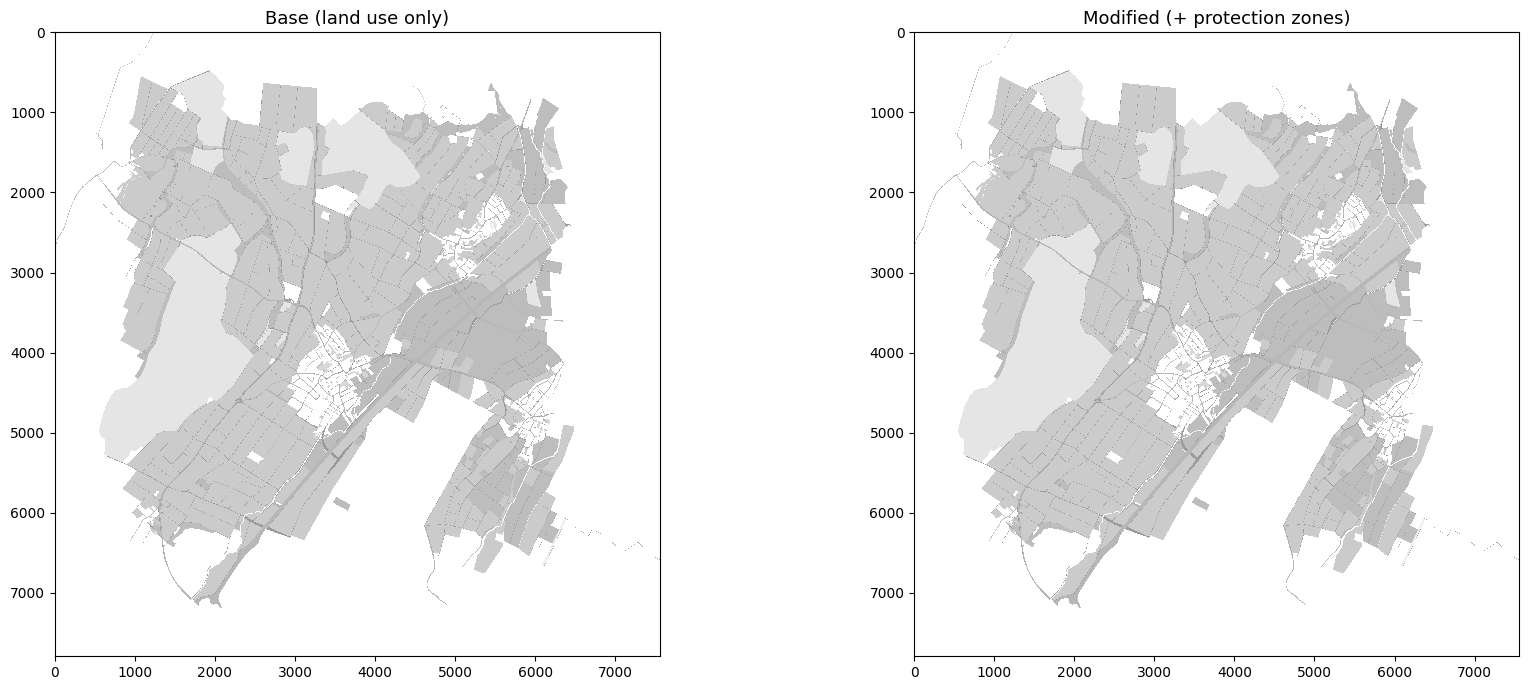

Forbidden cells:  33,819,794  ->  33,819,794


In [8]:
# Apply each protection layer to the base raster
for mod in datasets_to_modify:
    geo_rasterizer.modify_raster_from_dataset(**mod)

final_raster_path = "../tutorial/output/modified_cost_raster.tiff"
geo_rasterizer.save_raster(save_path=final_raster_path)

# Compare side by side
with rasterio.open(final_raster_path) as src:
    mod_data = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, title in zip(axes, [base_data, mod_data],
                            ["Base (land use only)", "Modified (+ protection zones)"]):
    plot_cost_raster(ax, data, title=title)
plt.tight_layout()
plt.show()

print(f"Forbidden cells:  {(base_data == 65535).sum():>8,d}  ->  {(mod_data == 65535).sum():>8,d}")

## 1.6 Shortcut: All-in-One with PathFinder

`PathFinder` can handle rasterisation **and** modification internally &mdash; no need
to create `GeoRasterizer` manually. Pass the WFS dict as `dataset_source`, the cost
assumptions, and the `datasets_to_modify` list directly:

Path(id=0, source=(411200, 5361300), target=(414500, 5362500), length_m=4830.50, cost=490398.03)


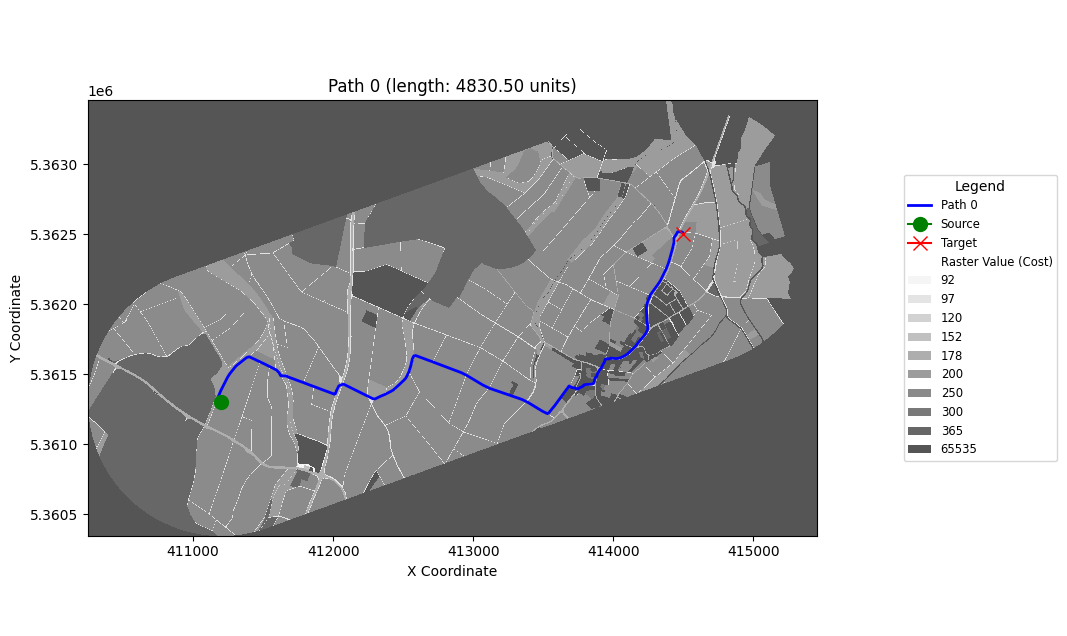

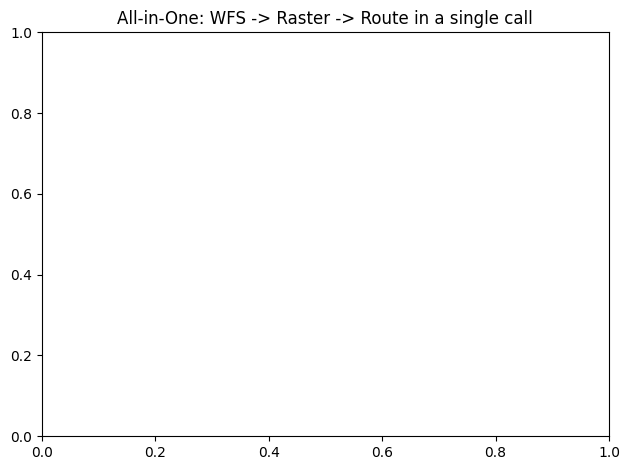

In [9]:
# Define source and target on passable land (farmland area, away from villages)
source_custom = (411200, 5361300)
target_custom = (414500, 5362500)

pf_onestep = PathFinder(
    dataset_source=alkis_wfs,
    cost_assumptions=base_cost_assumptions,
    datasets_to_modify=datasets_to_modify,
    bbox=bbox_tutorial,
    source_coords=source_custom,
    target_coords=target_custom,
    raster_save_path="../tutorial/output/onestep_raster.tiff",
)
path_onestep = pf_onestep.find_route()
print(path_onestep)

pf_onestep.plot_paths()
plt.title("All-in-One: WFS -> Raster -> Route in a single call")
plt.tight_layout()
plt.show()

### Part 1 Summary

| Step | Data source | Effect |
|------|------------|--------|
| Base | ALKIS land use (LGL BW) | Construction costs per terrain |
| +1 | Naturschutzgebiete (LUBW) | Forbidden zones |
| +2 | Vogelschutzgebiete (LUBW) | &times;1.75 surcharge |
| +3 | Wasserschutzgebiete (LUBW) | &times;1.5 surcharge |
| +4 | Landschaftsschutzgebiete (LUBW) | &times;1.25 surcharge |

> **Tip:** Add as many layers as needed (soil conditions, flood zones,
> infrastructure buffers, &hellip;). `modify_raster_from_dataset()` accepts any WFS
> or local vector/raster source. For quick workflows, pass everything to
> `PathFinder` directly.

---
# Part 2: Path Finding with Different Neighborhoods &amp; Search Spaces

Now that we have a cost raster, we explore how **neighborhood degree** and
**search space** affect routing results.

## 2.1 Default Route (R2, Full Search Space)

We start with the default settings: **R2** neighborhood (16 directions) and
no search-space restriction.

Path(id=0, source=(411200, 5361300), target=(414500, 5362500), length_m=4830.50, cost=490398.03)

Length: 4830 m | Cost: 490398 EUR | Detour: 1.38x


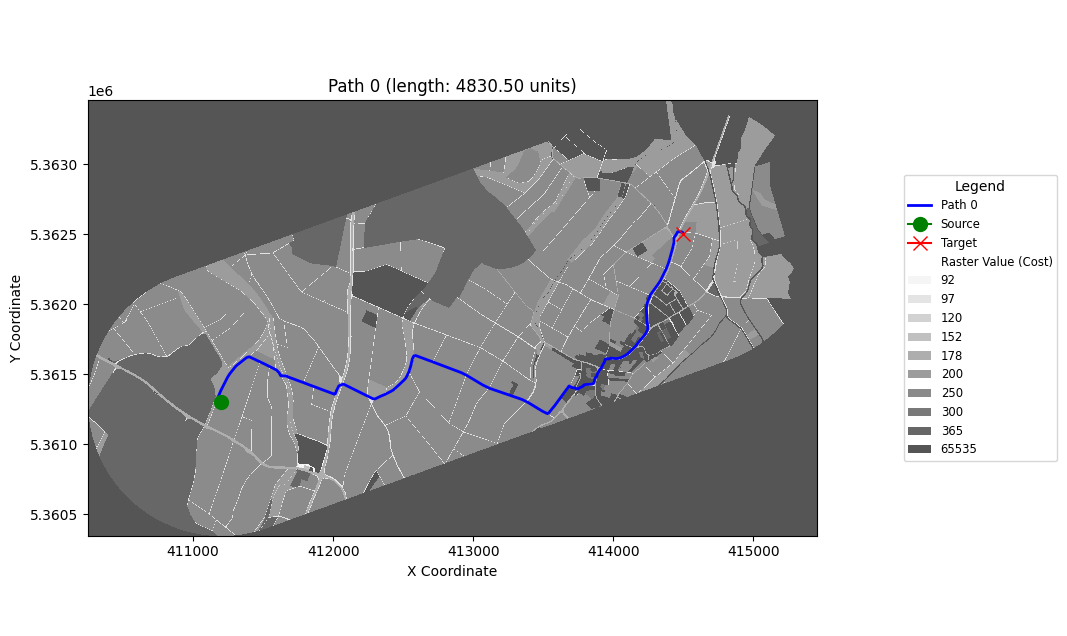

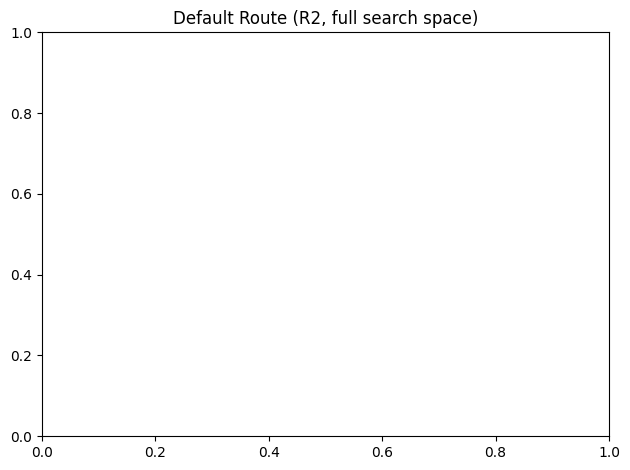

In [10]:
pf_default = PathFinder(
    dataset_source=final_raster_path,
    source_coords=source_custom,
    target_coords=target_custom,
)
path_default = pf_default.find_route()
print(path_default)
print(f"\nLength: {path_default.total_length:.0f} m | Cost: {path_default.total_cost:.0f} EUR "
      f"| Detour: {path_default.total_length / path_default.euclidean_distance:.2f}x")

pf_default.plot_paths()
plt.title("Default Route (R2, full search space)")
plt.tight_layout()
plt.show()

## 2.2 Neighborhood Strategies (R0&ndash;R3)

The **neighborhood degree** controls how many directions the algorithm considers
at each pixel:

| Neighborhood | Directions | Max Angular Error | Description |
|:---:|:---:|:---:|---|
| R0 | 4 | 41.4% | Cardinal only (N, S, E, W) |
| R1 | 8 | 7.6% | + diagonals |
| **R2** | **16** | **1.8%** | **+ knight's moves (default)** |
| R3 | 32 | 1.1% | + extended knight's moves |

Higher neighborhoods produce smoother, more accurate paths but require more computation.
Let's compare all four on our custom raster:

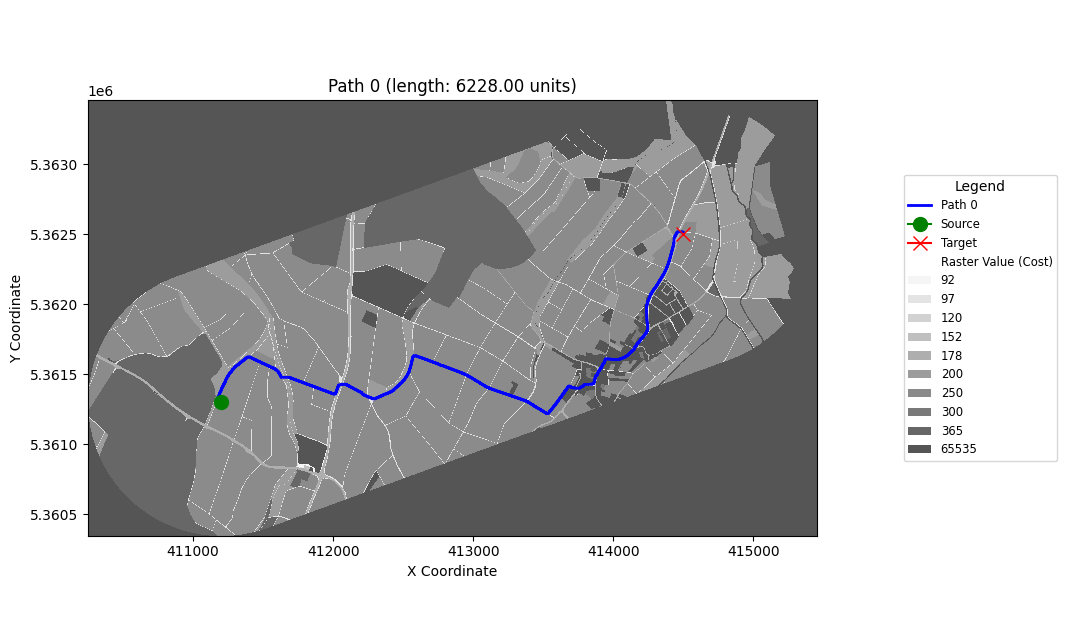

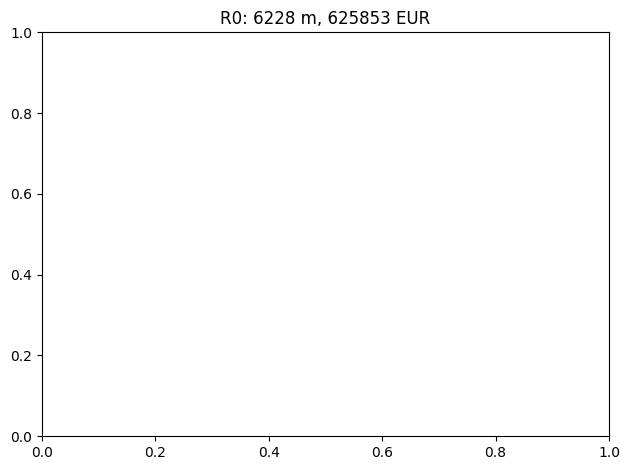

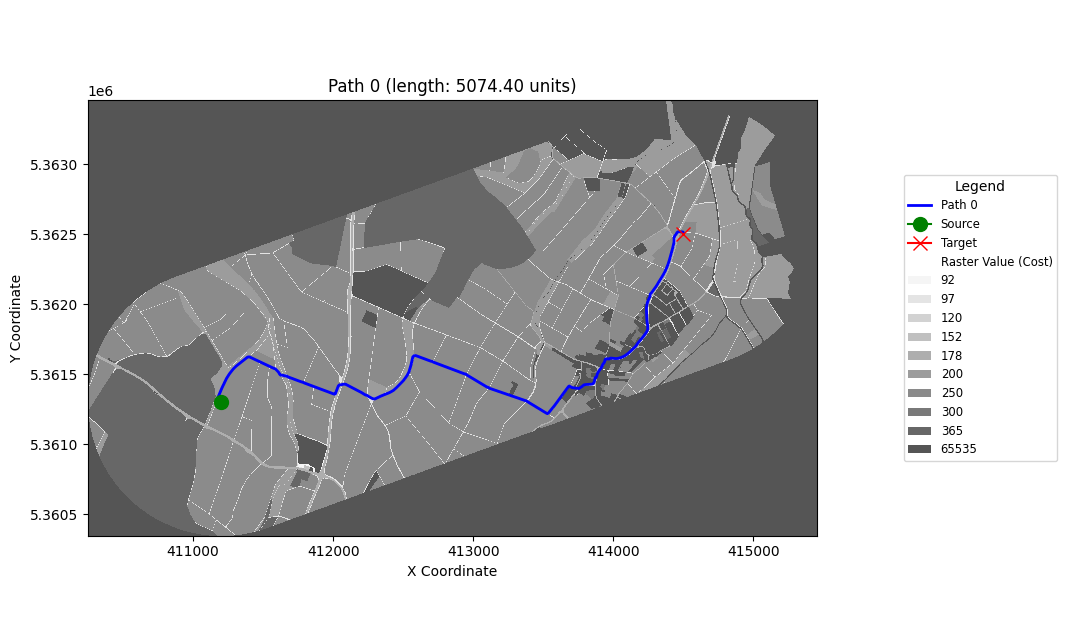

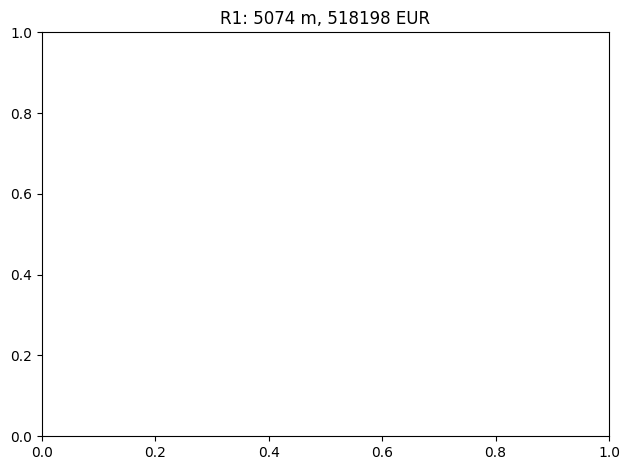

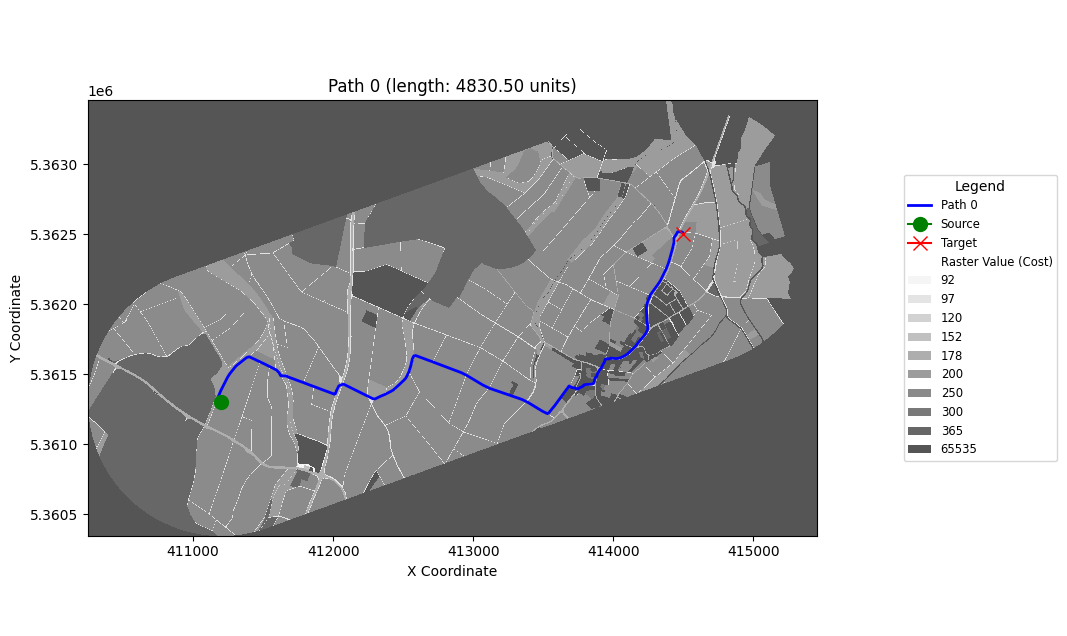

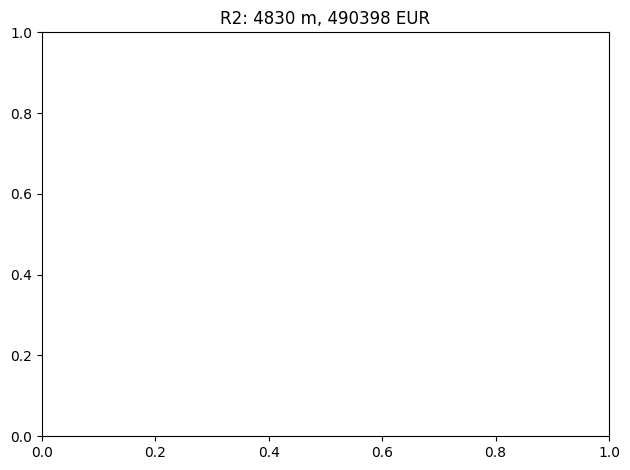

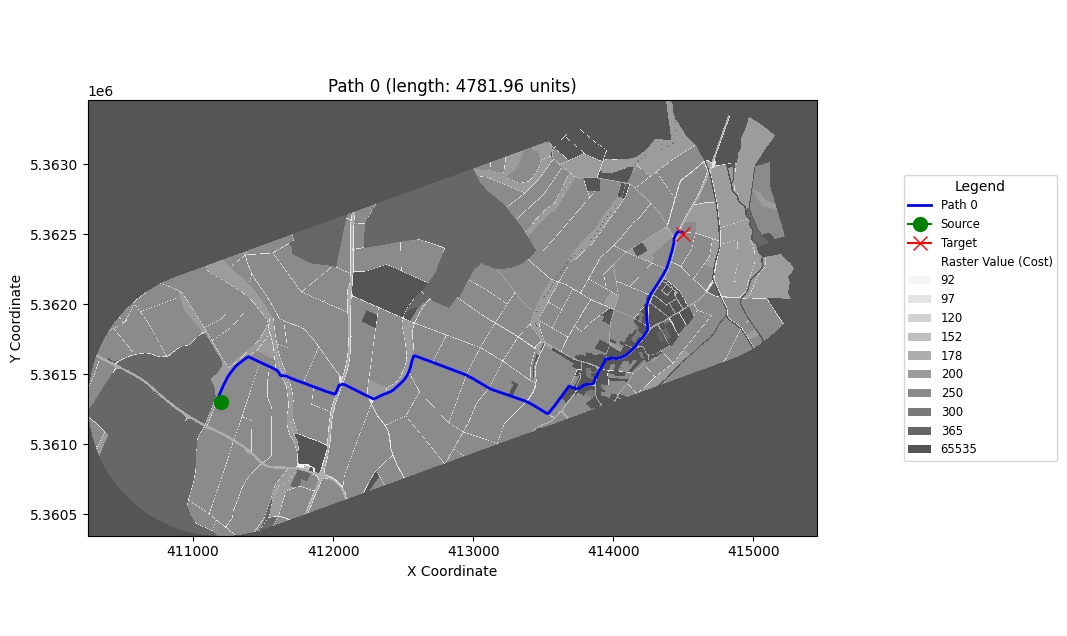

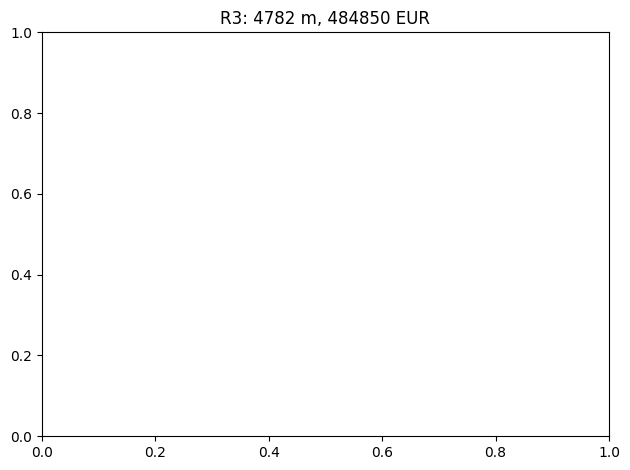


Nbh    Directions   Length (m)   Cost (EUR)    
--------------------------------------------
R0     4            6228.0       625853.0      
R1     8            5074.4       518198.1      
R2     16           4830.5       490398.0      
R3     32           4782.0       484849.7      


In [11]:
results_nbh = {}
for r in ["r0", "r1", "r2", "r3"]:
    pf_nbh = PathFinder(
        dataset_source=final_raster_path,
        source_coords=source_custom,
        target_coords=target_custom,
        neighborhood_str=r,
    )
    p = pf_nbh.find_route()
    results_nbh[r] = p
    pf_nbh.plot_paths()
    plt.title(f"{r.upper()}: {p.total_length:.0f} m, {p.total_cost:.0f} EUR")
    plt.tight_layout()
    plt.show()

# Summary table
print(f"\n{'Nbh':<6} {'Directions':<12} {'Length (m)':<12} {'Cost (EUR)':<14}")
print("-" * 44)
for r, p in results_nbh.items():
    n_dirs = {"r0": 4, "r1": 8, "r2": 16, "r3": 32}[r]
    print(f"{r.upper():<6} {n_dirs:<12} {p.total_length:<12.1f} {p.total_cost:<14.1f}")

### Key Takeaway

- **R0** produces staircase-like paths (only horizontal/vertical movement)
- **R2** (default) offers excellent accuracy with moderate cost
- **R3** provides marginal improvement over R2 at higher computational cost
- For most applications, **R2 is the recommended choice**

## 2.3 Varying the Search Space

By default, PYORPS searches the **entire raster**. The `search_space_buffer_m` parameter
restricts the search to a rectangular buffer around source and target. A tighter buffer
speeds up computation but may miss detours around large obstacles.

| Buffer | Effect |
|--------|--------|
| `None` (default) | Full raster &mdash; guaranteed global optimum |
| Large (e.g. 2000&nbsp;m) | Fast, still finds most detours |
| Small (e.g. 500&nbsp;m) | Very fast, but may miss routes around wide obstacles |

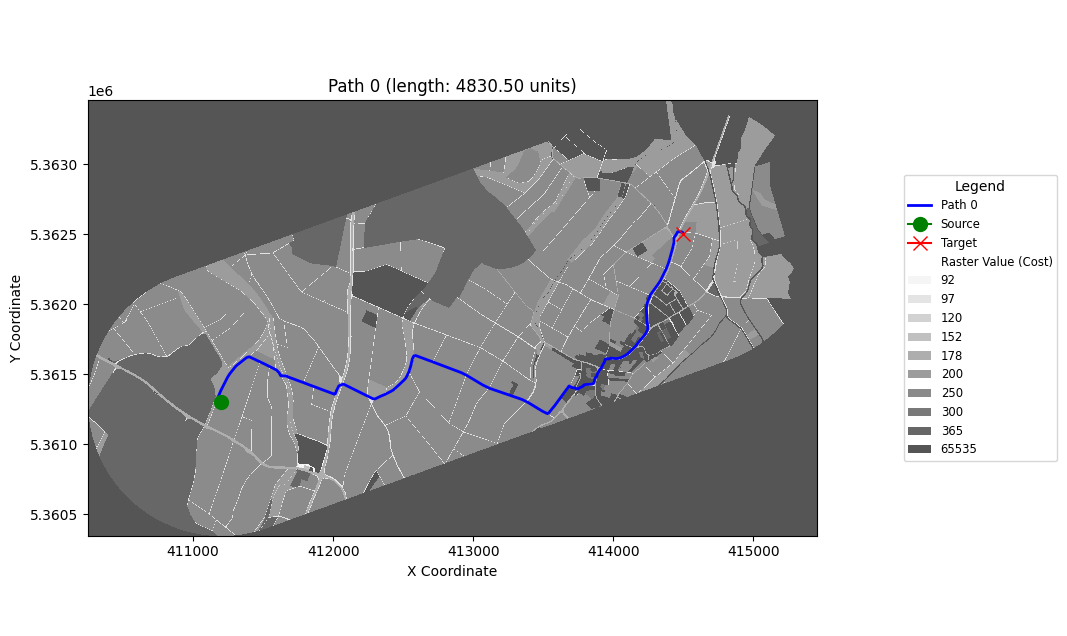

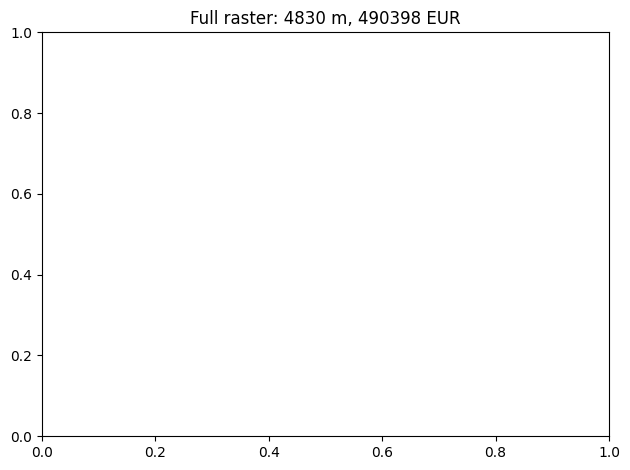

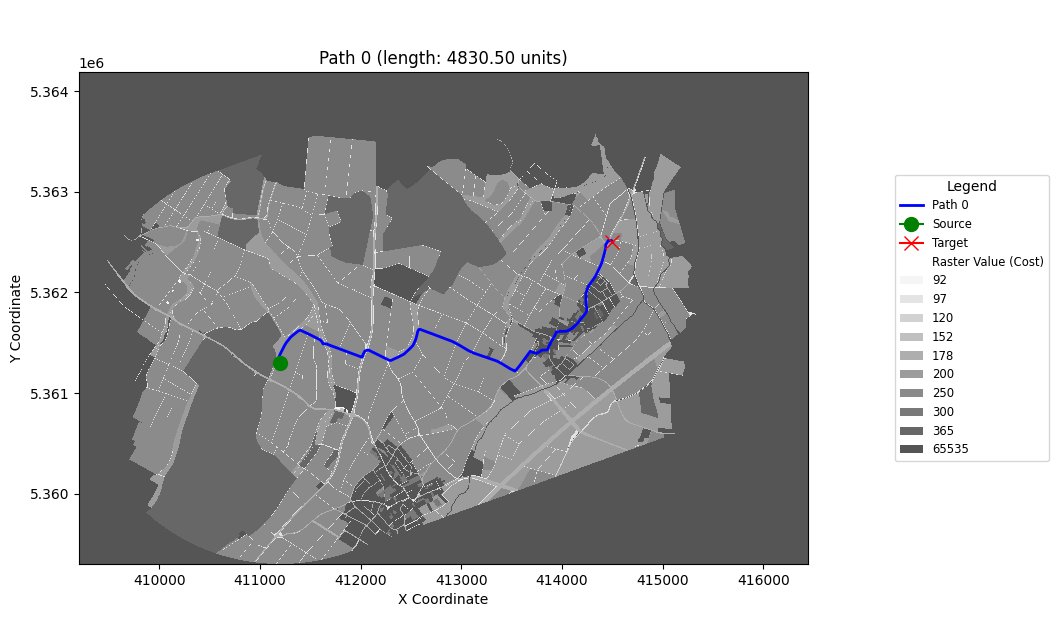

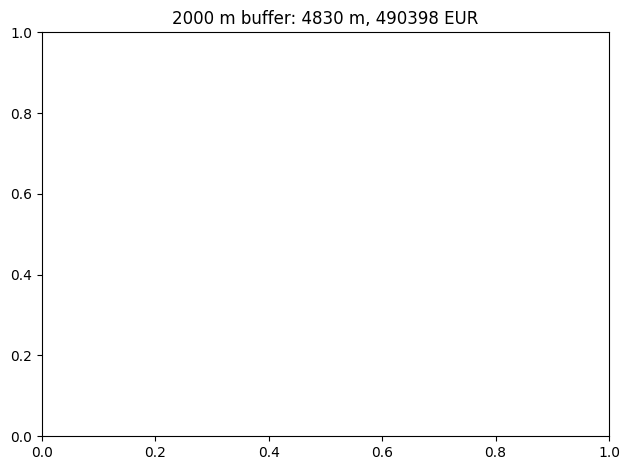

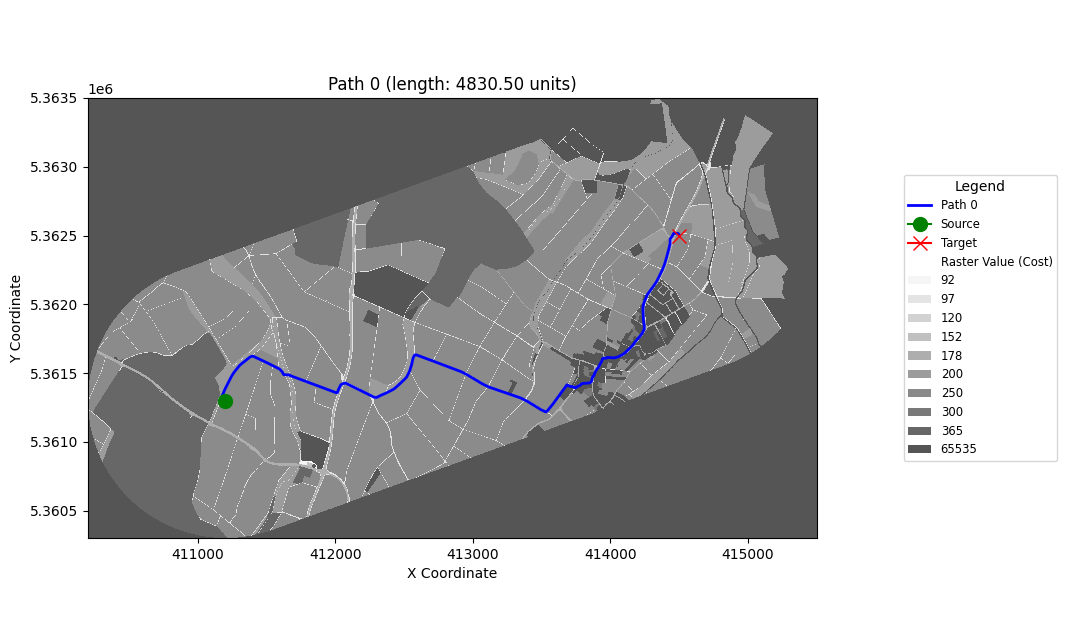

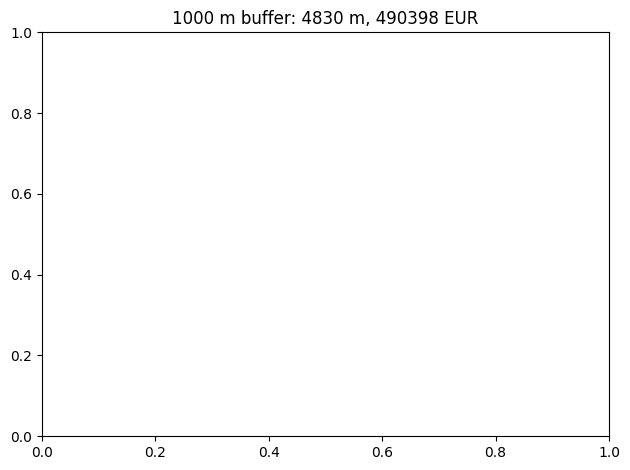

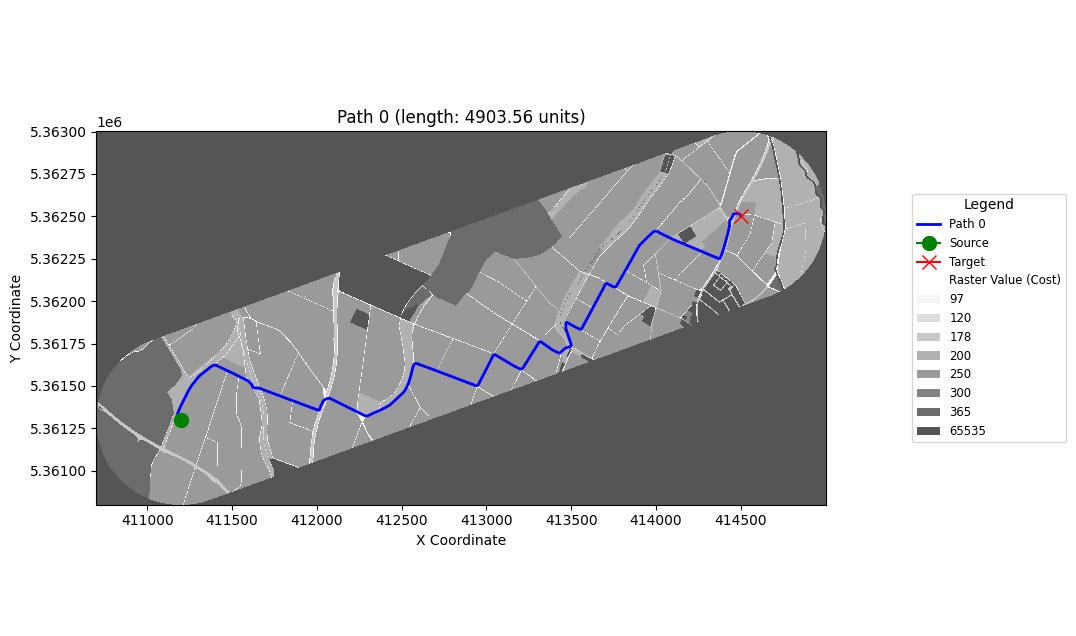

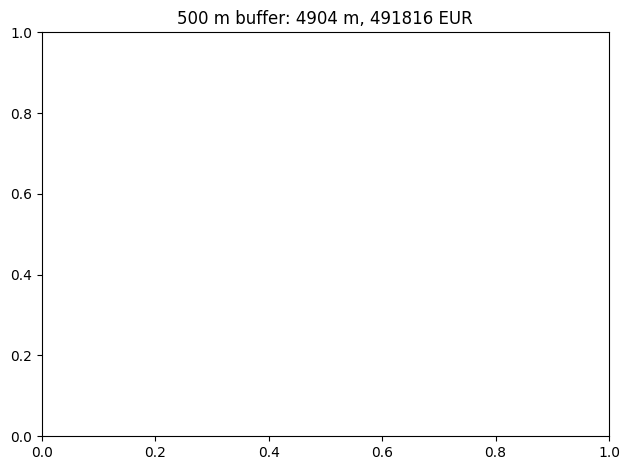


Buffer         Length (m)   Cost (EUR)    
----------------------------------------
Full raster    4830.5       490398.0      
2000 m         4830.5       490398.0      
1000 m         4830.5       490398.0      
500 m          4903.6       491816.5      


In [12]:
buffers = [None, 2000, 1000, 500]
results_buf = {}

for buf in buffers:
    label = "Full raster" if buf is None else f"{buf} m buffer"
    pf_buf = PathFinder(
        dataset_source=final_raster_path,
        source_coords=source_custom,
        target_coords=target_custom,
        search_space_buffer_m=buf,
    )
    try:
        p = pf_buf.find_route()
        results_buf[buf] = p
        pf_buf.plot_paths()
        plt.title(f"{label}: {p.total_length:.0f} m, {p.total_cost:.0f} EUR")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        results_buf[buf] = None
        print(f"{label}: {e}")

# Summary table
print(f"\n{'Buffer':<14} {'Length (m)':<12} {'Cost (EUR)':<14}")
print("-" * 40)
for buf, p in results_buf.items():
    label = "Full raster" if buf is None else f"{buf} m"
    if p is not None:
        print(f"{label:<14} {p.total_length:<12.1f} {p.total_cost:<14.1f}")
    else:
        print(f"{label:<14} {'No path found'}")

---
# Part 3: Case Study 1 &mdash; PCC Optimization for Utility-Scale PV Systems

## Scenario

A **1 MVA photovoltaic (PV) system** needs to be connected to the medium-voltage (MV) grid. We need to determine the **optimal point of common coupling (PCC)** considering:

- **Construction costs** (terrain-dependent cable routing)
- **Technical feasibility** (voltage limits, equipment loading)
- **Path quality** (via different neighborhood strategies)

We use the **MV Oberrhein** benchmark network from pandapower.

## 3.1 Load Network &amp; Define PV Site

Buses: 193 | Trafo stations: 84 | Lines: 109 | Generators: 93


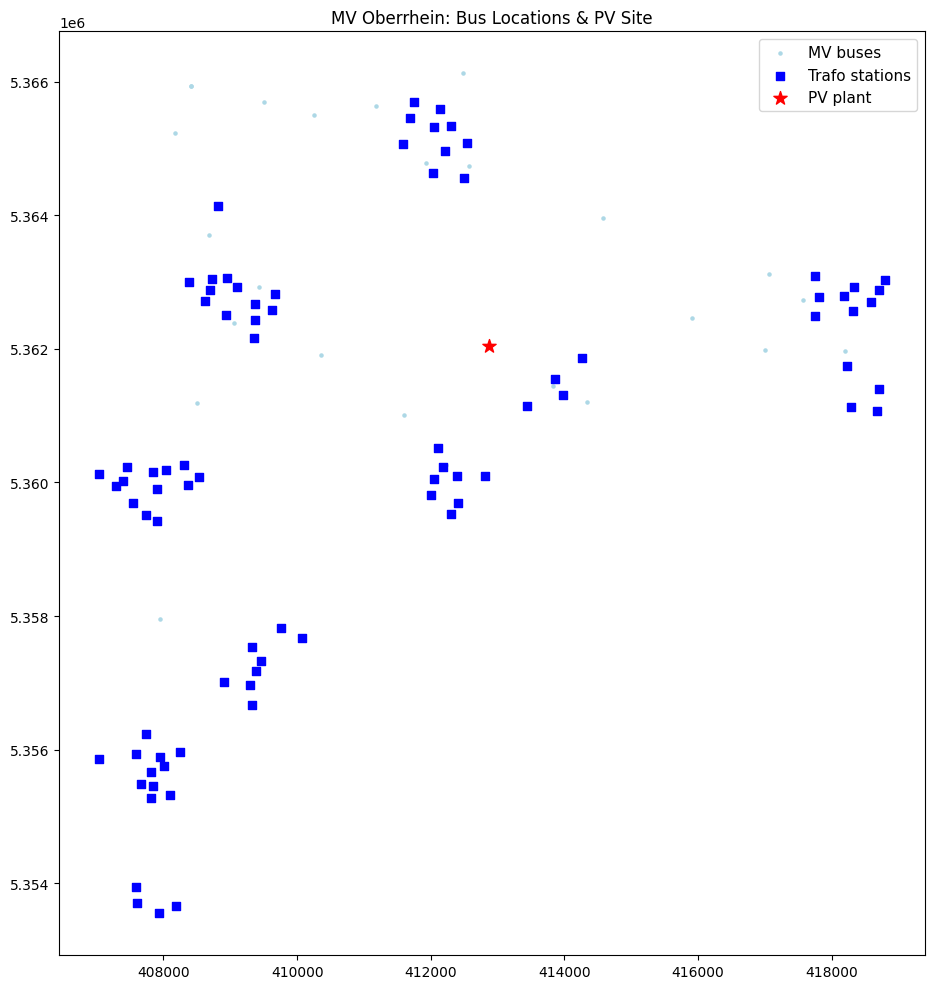

In [13]:
# Load the MV Oberrhein network
net = pp.networks.mv_oberrhein(
    scenario='generation', separation_by_sub=True, include_substations=True
)[1]

net_crs = "EPSG:4326"
gis_crs = "EPSG:25832"

def get_bus_geoseries(net, net_crs, buses=None):
    if buses is None:
        buses = net.bus.index
    return net.bus.loc[buses].geo.geojson.as_geoseries.to_crs(crs=net_crs)

all_bus_geo = get_bus_geoseries(net, net_crs).to_crs(gis_crs)
trafo_hv_buses = net.bus.loc[
    net.bus.index.isin(net.trafo.hv_bus) & (net.bus.vn_kv == 20)
].index.tolist()
trafo_bus_geo = get_bus_geoseries(net, net_crs, trafo_hv_buses).to_crs(gis_crs)

pv_location = Point(412874, 5362043)
pv_geoseries = gpd.GeoSeries([pv_location], crs=gis_crs)

print(f"Buses: {len(net.bus)} | Trafo stations: {len(trafo_bus_geo)} | "
      f"Lines: {len(net.line)} | Generators: {len(net.sgen)}")

fig, ax = plt.subplots(figsize=(12, 10))
all_bus_geo.plot(ax=ax, color='lightblue', markersize=5, label='MV buses')
trafo_bus_geo.plot(ax=ax, color='blue', markersize=30, marker='s', label='Trafo stations')
pv_geoseries.plot(ax=ax, color='red', markersize=100, marker='*', zorder=5, label='PV plant')
ax.legend(fontsize=11)
ax.set_title("MV Oberrhein: Bus Locations & PV Site")
plt.tight_layout()
plt.show()

## 3.2 Find Candidate PCCs

Identify the **8 nearest transformer stations** to the PV plant.

In [14]:
n_candidates = 8
distances = trafo_bus_geo.distance(pv_location).sort_values()
closest_buses = distances.head(n_candidates).index.tolist()
closest_geo = trafo_bus_geo.loc[closest_buses]

for bus_idx in closest_buses:
    print(f"  Bus {bus_idx}: {distances.loc[bus_idx]:.0f} m")

  Bus 138: 1060 m
  Bus 170: 1103 m
  Bus 111: 1330 m
  Bus 136: 1406 m
  Bus 133: 1708 m
  Bus 140: 1934 m
  Bus 141: 1940 m
  Bus 172: 2009 m


## 3.3 Load the Cost Raster

We use a pre-computed raster for the full MV Oberrhein area (same cost assumptions
as Part 2, but covering the larger network footprint).

Raster: (25734, 22544), 1.0 m/pixel


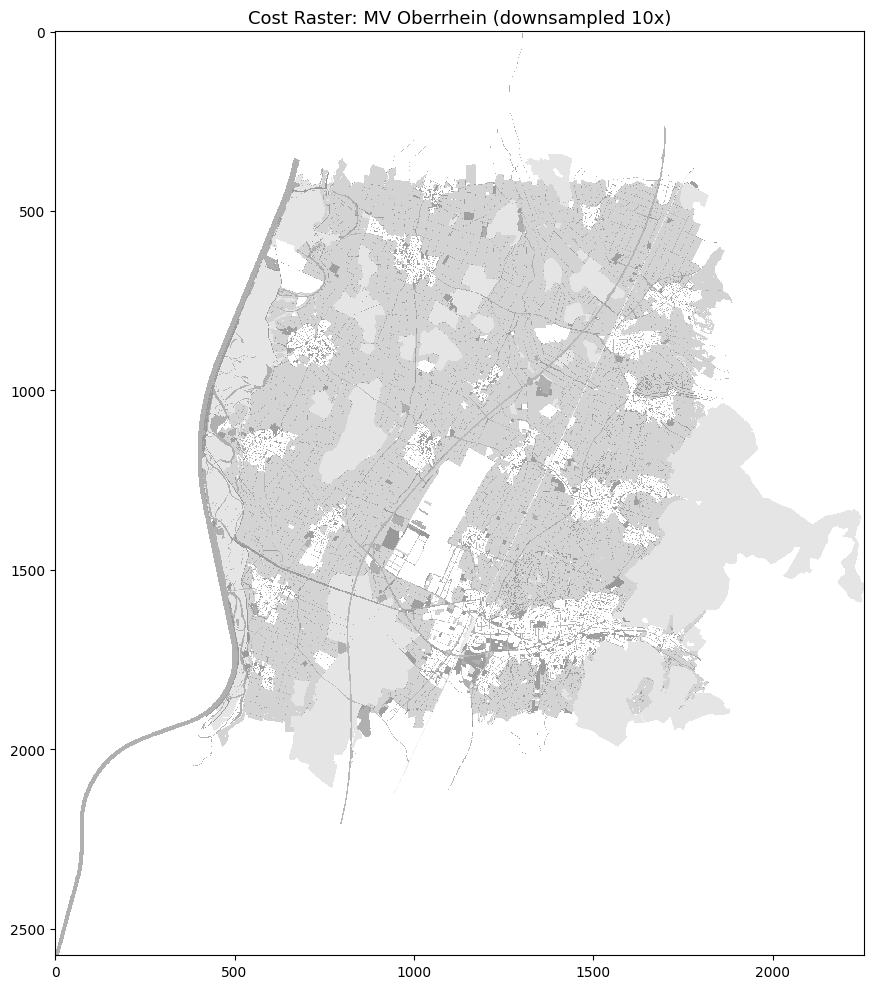

In [15]:
# Pre-computed raster covering the full MV Oberrhein network area
raster_path_oberrhein = "../case_studies/mv_oberrhein/data/raster/mv_oberrhein_new.tiff"

with rasterio.open(raster_path_oberrhein) as src:
    raster_data = src.read(1)
    print(f"Raster: {raster_data.shape}, {abs(src.transform.a):.1f} m/pixel")

step = max(1, max(raster_data.shape) // 2500)
fig, ax = plt.subplots(figsize=(14, 10))
plot_cost_raster(ax, raster_data[::step, ::step],
                 title=f"Cost Raster: MV Oberrhein (downsampled {step}x)")
plt.tight_layout()
plt.show()

## 3.4 Find Optimal Routes to All Candidate PCCs

PYORPS supports **single-source, multi-target** routing &mdash; one Dijkstra run
finds paths to all candidates at once.

C:\Users\mhnn82\Documents\2_python_projects\pyorps\pyorps\graph\path_finder.py:593: UserWarning: 4 position(s) had maximum cost value (65535) and were corrected:
     Orig Coords        Orig Idx     Corr Coords        Corr Idx
  (413978.8, 5361302.3)    [1395, 2530]    ->  (413985.8, 5361295.3)    [1402, 2537]
  (414269.8, 5361869.3)     [828, 2821]    ->  (414251.8, 5361857.3)     [840, 2803]
  (412809.7, 5360104.3)    [2593, 1361]    ->  (412812.7, 5360105.3)    [2592, 1364]
  (412397.7, 5360091.3)     [2606, 949]    ->  (412397.7, 5360092.3)     [2605, 949]

  indices_2d = self._correct_max_cost_positions(indices_2d)


  Path 0: 1288 m, 148072 EUR
  Path 1: 1164 m, 143225 EUR
  Path 2: 1563 m, 201253 EUR
  Path 3: 1676 m, 196183 EUR
  Path 4: 2001 m, 238403 EUR
  Path 5: 2480 m, 266789 EUR
  Path 6: 2661 m, 264161 EUR
  Path 7: 2585 m, 254932 EUR


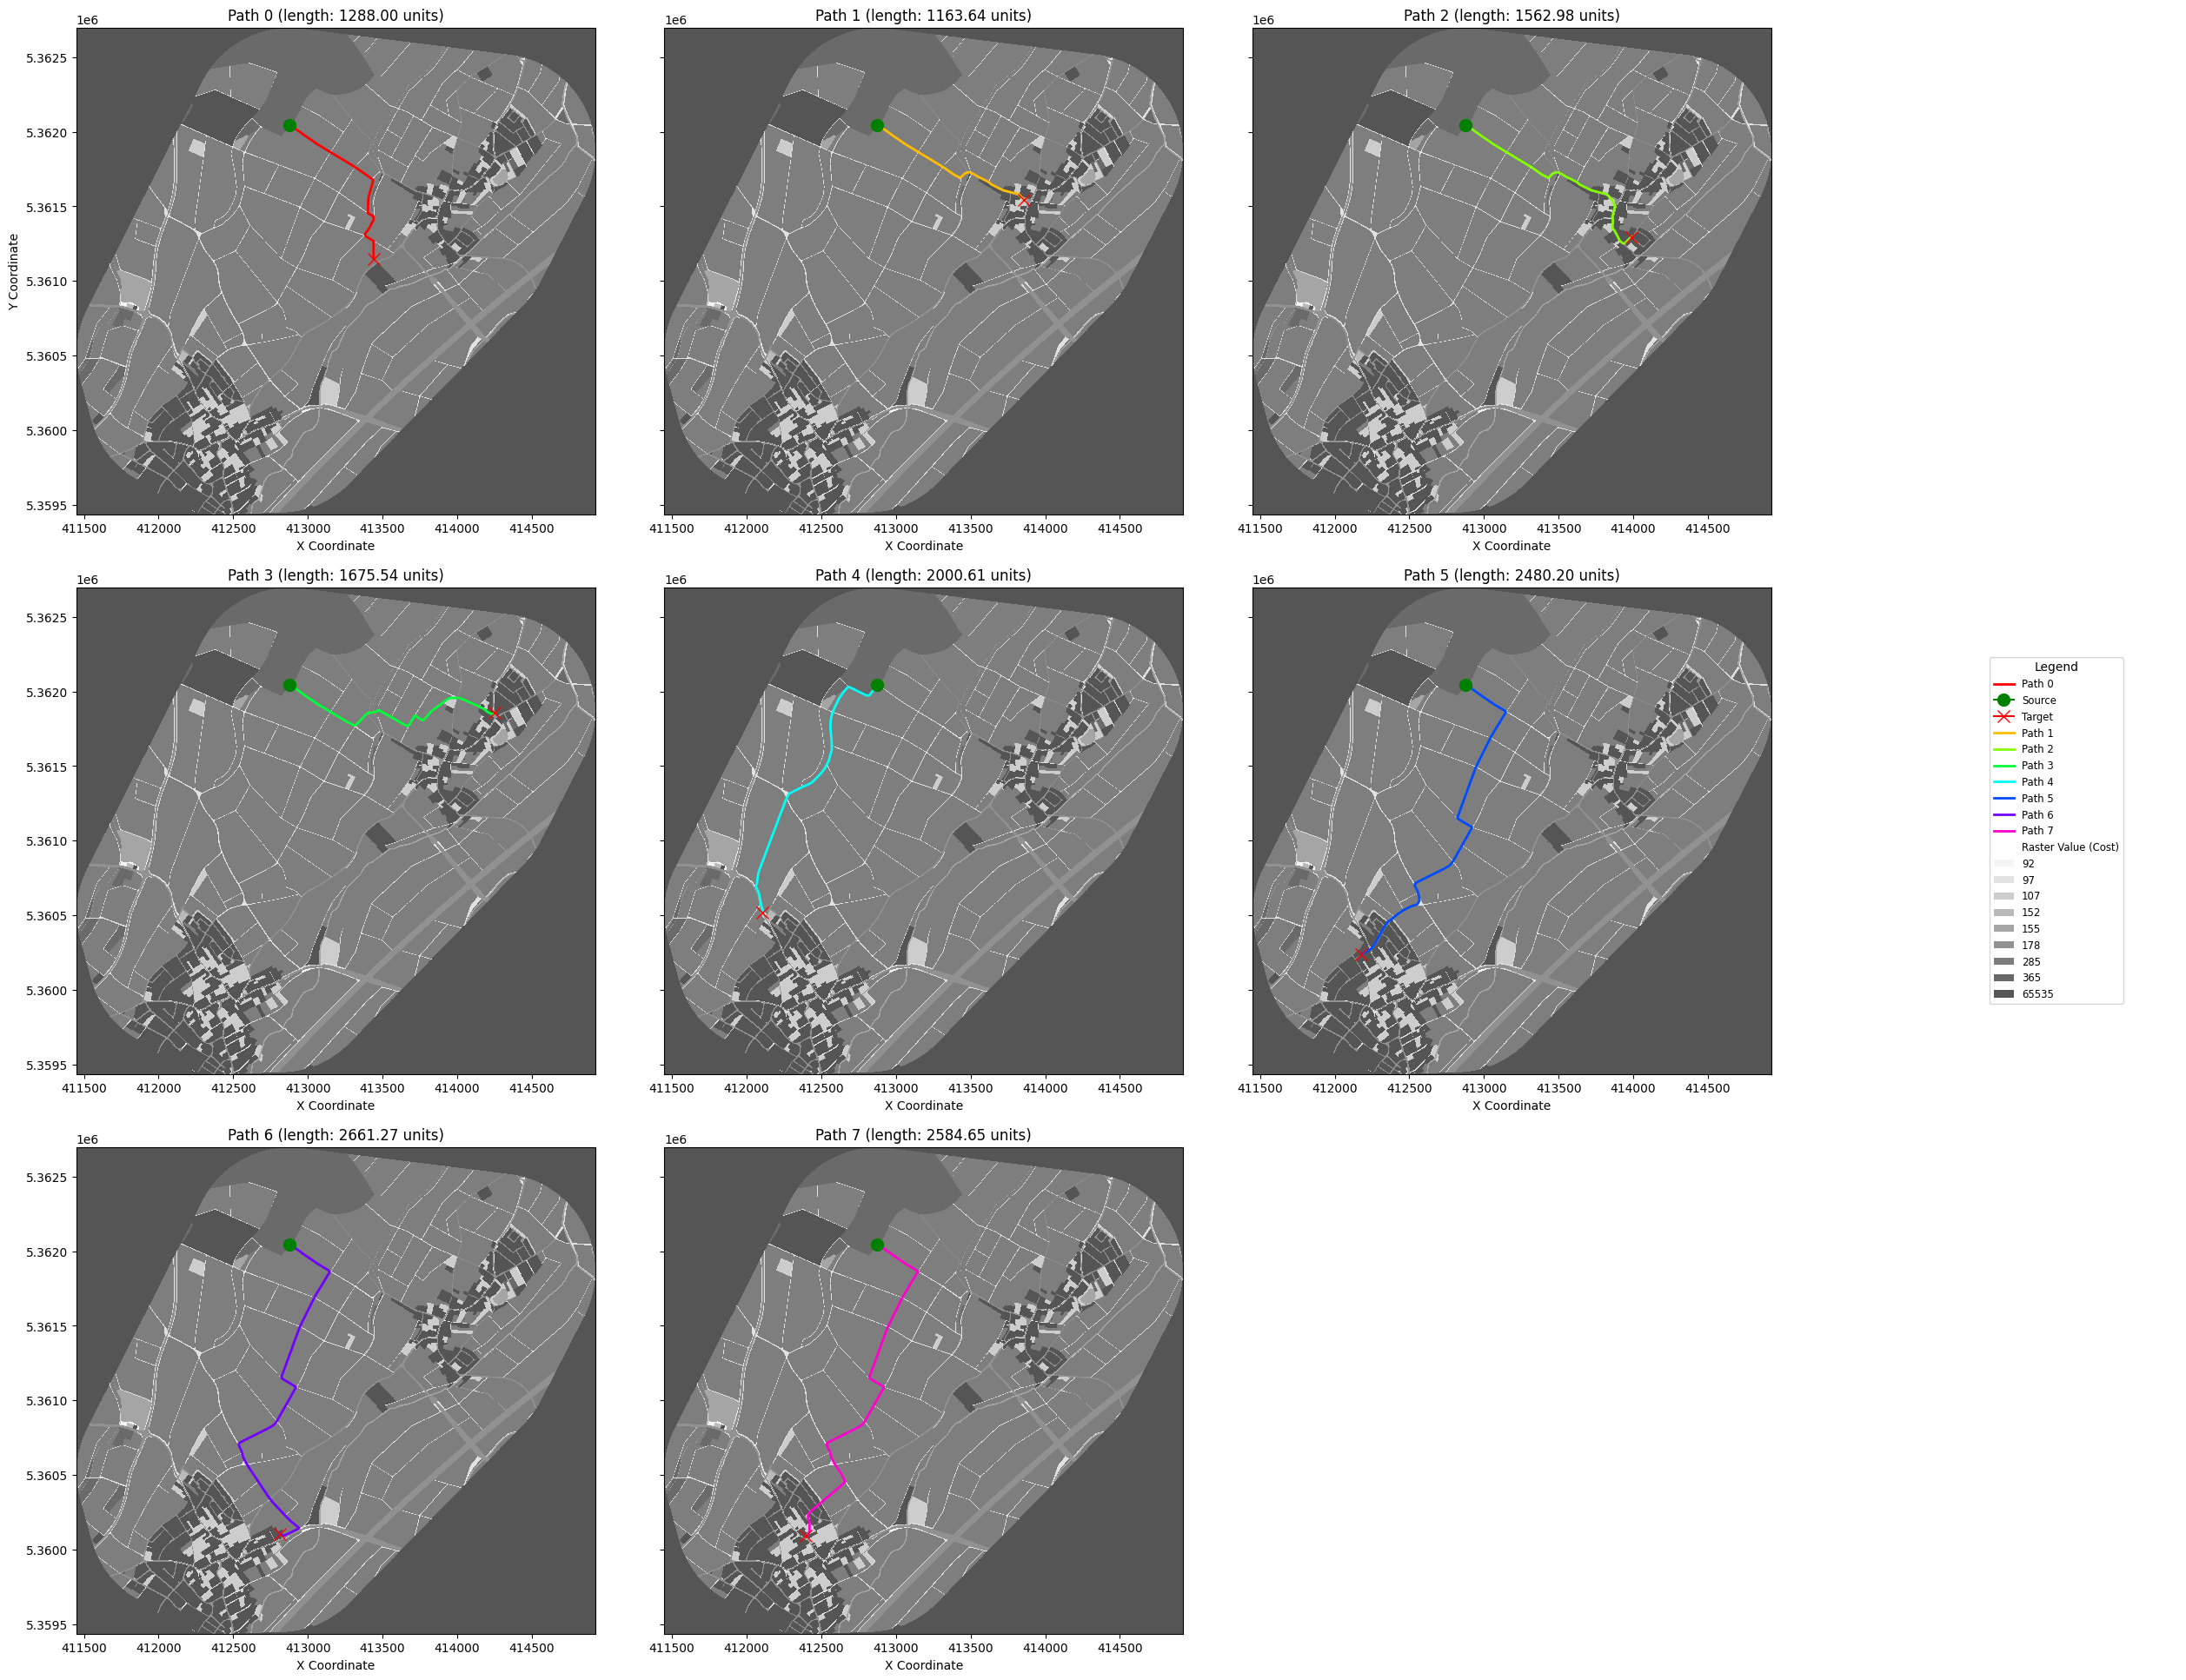

<Figure size 640x480 with 0 Axes>

In [16]:
pf = PathFinder(
    dataset_source=raster_path_oberrhein,
    source_coords=pv_geoseries,
    target_coords=closest_geo,
    neighborhood_str="r2",
    ignore_max_cost=True,
)
pf.find_route()
all_paths = pf.paths  # PathCollection with all results

for p in all_paths:
    print(f"  Path {p.path_id}: {p.total_length:.0f} m, {p.total_cost:.0f} EUR")

pf.plot_paths()
plt.suptitle("Candidate Routes: PV Plant to Transformer Stations")
plt.tight_layout()
plt.show()

## 3.5 Technical Validation with Power Flow Analysis

For each candidate route: add a cable to the network, run power flow, check voltage
limits and equipment loading.

In [17]:
# Fresh network copy for PV connection analysis
net_pcc = pp.networks.mv_oberrhein(
    scenario='generation', separation_by_sub=True, include_substations=True
)[1]
net_pcc.ext_grid.vm_pu = 1.04
p_mw, q_mvar = pp.pq_from_cosphi(
    net_pcc.sgen.sn_mva, cosphi=0.90, qmode="underexcited", pmode="gen")
net_pcc.sgen.p_mw = p_mw
net_pcc.sgen.q_mvar = q_mvar
net_pcc.sgen.scaling = 0.7

pv_bus = pp.create_bus(net_pcc, vn_kv=20, name='PV-Site')
pp.create_sgen_from_cosphi(net_pcc, bus=pv_bus, sn_mva=1.0,
                            mode="underexcited", cos_phi=0.90)
net_pcc.sgen.iloc[-1, net_pcc.sgen.columns.get_loc('scaling')] = 0.7
original_sgen_p = net_pcc.sgen.p_mw.values.copy()
line_type = "NA2XS2Y 1x95 RM/25 12/20 kV"

In [18]:
# Match each path target to its nearest bus using vectorised distance
target_points = gpd.GeoSeries([Point(p.target) for p in all_paths], crs=gis_crs)
target_buses = [trafo_bus_geo.distance(pt).idxmin() for pt in target_points]
lengths_km = np.array([p.total_length for p in all_paths]) / 1000

# Add ALL candidate lines at once (out of service) using batch API
candidate_line_ids = pp.create_lines(
    net_pcc,
    from_buses=np.repeat(pv_bus, len(target_buses)),
    to_buses=target_buses,
    length_km=lengths_km,
    std_type=line_type,
    in_service=False,  # All out of service initially
    name=[f"PCC_{tb}" for tb in target_buses],
)

# Evaluate each candidate: enable one line at a time, run power flow, record metrics
pcc_results = []

for i, line_id in enumerate(candidate_line_ids):
    net_pcc.line.at[line_id, 'in_service'] = True
    pp.runpp(net_pcc)

    # Recompute mask after runpp (bus count may change with new line)
    sgen_bus_mask = net_pcc.res_bus.index.isin(net_pcc.sgen.bus)

    result = {
        'Target Bus': target_buses[i],
        'Line length [km]': lengths_km[i],
        'V at PV [p.u.]': net_pcc.res_bus.at[pv_bus, 'vm_pu'],
        'Min V [p.u.]': net_pcc.res_bus.vm_pu.min(),
        'Max V [p.u.]': net_pcc.res_bus.vm_pu.max(),
        'Line loading [%]': net_pcc.res_line.at[line_id, 'loading_percent'],
        'Max line loading [%]': net_pcc.res_line.loading_percent.max(),
    }

    # Voltage rise: full generation vs. zero generation
    v_with_gen = net_pcc.res_bus.loc[sgen_bus_mask, 'vm_pu'].values.copy()
    net_pcc.sgen.p_mw = 0
    pp.runpp(net_pcc)
    v_without_gen = net_pcc.res_bus.loc[sgen_bus_mask, 'vm_pu'].values
    result['Voltage rise [p.u.]'] = (v_with_gen - v_without_gen).max()

    # Restore state
    net_pcc.sgen.p_mw = original_sgen_p
    net_pcc.line.at[line_id, 'in_service'] = False

    p = all_paths.all[i]
    result['Path cost [EUR]'] = p.total_cost
    result['Path length [m]'] = p.total_length
    result['Path ID'] = p.path_id
    pcc_results.append(result)

# Clean up: remove all candidate lines
net_pcc.line.drop(candidate_line_ids, inplace=True)

results_df = pd.DataFrame(pcc_results)
print("\nPCC Evaluation Results:")
print(results_df.to_string(index=False))


PCC Evaluation Results:
 Target Bus  Line length [km]  V at PV [p.u.]  Min V [p.u.]  Max V [p.u.]  Line loading [%]  Max line loading [%]  Voltage rise [p.u.]  Path cost [EUR]  Path length [m]  Path ID
        138          1.287999        1.036031      1.021845          1.04          7.739875             23.382826             0.024688    148071.876486      1287.998727        0
        170          1.163639        1.035813      1.021820          1.04          7.741505             23.396350             0.024537    143224.530129      1163.639309        1
        111          1.562981        1.036189      1.021901          1.04          7.738701             23.355104             0.024601    201252.744216      1562.980882        2
        136          1.675541        1.036046      1.021925          1.04          7.739769             23.345121             0.024383    196182.516880      1675.540958        3
        133          2.000610        1.029970      1.021891          1.04          7.

## 3.6 Select the Optimal PCC

Filter for technically valid options (voltage rise &lt; 0.02 p.u., bus voltages
0.95&ndash;1.05 p.u., loading &lt; 50%) and pick the cheapest.

In [19]:
valid = results_df[
    (results_df['Voltage rise [p.u.]'] < 0.02) &
    (results_df['Max V [p.u.]'] < 1.05) &
    (results_df['Min V [p.u.]'] > 0.95) &
    (results_df['Max line loading [%]'] < 50)
].sort_values('Path cost [EUR]')

print(f"Valid: {len(valid)} / {len(results_df)}")
if len(valid):
    best = valid.iloc[0]
    print(f"\nBest PCC: Bus {int(best['Target Bus'])}, "
          f"{best['Path length [m]']:.0f} m, {best['Path cost [EUR]']:.0f} EUR")
    print(valid[['Target Bus', 'Path length [m]', 'Path cost [EUR]',
                  'Voltage rise [p.u.]']].to_string(index=False))

Valid: 3 / 8

Best PCC: Bus 133, 2001 m, 238403 EUR
 Target Bus  Path length [m]  Path cost [EUR]  Voltage rise [p.u.]
        133      2000.609984    238402.838060             0.019582
        172      2584.646885    254932.073188             0.019582
        140      2480.198306    266788.805307             0.019582


### Case Study 1 Summary

We demonstrated a complete PCC optimization workflow:
1. **GIS data** provides terrain-aware construction costs
2. **PYORPS** finds optimal cable routes respecting terrain constraints
3. **Power flow analysis** validates technical feasibility
4. The cheapest *technically valid* option is selected

This process replaces manual route planning with data-driven, reproducible analysis.

---
# Part 4: Case Study 2 &mdash; Automated Grid Extension Planning

## Scenario

We demonstrate how PYORPS supports **automated grid extension planning** by:

1. **Identifying candidate connections** between MV stations using Delaunay triangulation
2. **Finding optimal cable routes** for each connection using PYORPS
3. **Building a network model** in pandapower
4. **Optimizing the topology** through iterative ring opening
5. **Evaluating cost vs. technical benefit** of each new cable

This addresses a critical gap: early-stage grid planning often neglects specific cable routing, leading to inaccurate cost estimates and suboptimal decisions.

## 4.1 Load Network &amp; Extract Station Locations

In [20]:
net_ext = pp.networks.mv_oberrhein(
    scenario='generation', separation_by_sub=True, include_substations=True
)[1]
pp.runpp(net_ext)

trafo_hv_buses_ext = net_ext.bus.loc[
    net_ext.bus.index.isin(net_ext.trafo.hv_bus) & (net_ext.bus.vn_kv == 20)
].index.tolist()
ext_grid_buses = net_ext.ext_grid.bus.tolist()

station_geo = get_bus_geoseries(net_ext, net_crs, trafo_hv_buses_ext).to_crs(gis_crs)
ext_grid_geo = get_bus_geoseries(net_ext, net_crs, ext_grid_buses).to_crs(gis_crs)

print(f"MV stations: {len(station_geo)} | "
      f"Max loading: {net_ext.res_line.loading_percent.max():.1f}% | "
      f"V: [{net_ext.res_bus.vm_pu.min():.4f}, {net_ext.res_bus.vm_pu.max():.4f}] p.u.")

MV stations: 84 | Max loading: 24.3% | V: [1.0000, 1.0244] p.u.


## 4.2 Apply Delaunay Triangulation

**Why Delaunay?** Connecting every pair of N stations would require N(N-1)/2 cables &mdash; far too many. Delaunay triangulation provides a **natural meshed topology** where each station connects to its geometric neighbors.

Properties of Delaunay triangulation:
- Maximizes the minimum angle of triangles (avoids very acute triangles)
- Every station connects to ~6 neighbors on average
- The resulting graph contains all possible minimum spanning trees
- Produces a reasonable meshed network that can be optimized further

In [21]:
# Extract coordinates for triangulation
coords = np.column_stack([station_geo.geometry.x, station_geo.geometry.y])
bus_indices = station_geo.index.values

print(f"Triangulating {len(coords)} station locations...")

# Apply Delaunay triangulation
tri = Delaunay(coords)

# Extract unique edges from the triangulation
edges = set()
for simplex in tri.simplices:
    for i in range(3):
        edge = tuple(sorted([simplex[i], simplex[(i + 1) % 3]]))
        edges.add(edge)

# Convert to bus index pairs
delaunay_connections = [
    (bus_indices[e[0]], bus_indices[e[1]]) for e in edges
]

print(f"Delaunay edges: {len(delaunay_connections)}")
print(f"Average connections per station: {2 * len(delaunay_connections) / len(coords):.1f}")

# Filter out very long connections (optional, e.g., > 5 km)
max_distance = 5000  # meters
filtered_connections = []
for fb, tb in delaunay_connections:
    dist = station_geo.loc[fb].distance(station_geo.loc[tb])
    if dist <= max_distance:
        filtered_connections.append((fb, tb))

print(f"After filtering (< {max_distance/1000:.0f} km): {len(filtered_connections)} connections")

Triangulating 84 station locations...
Delaunay edges: 238
Average connections per station: 5.7
After filtering (< 5 km): 229 connections


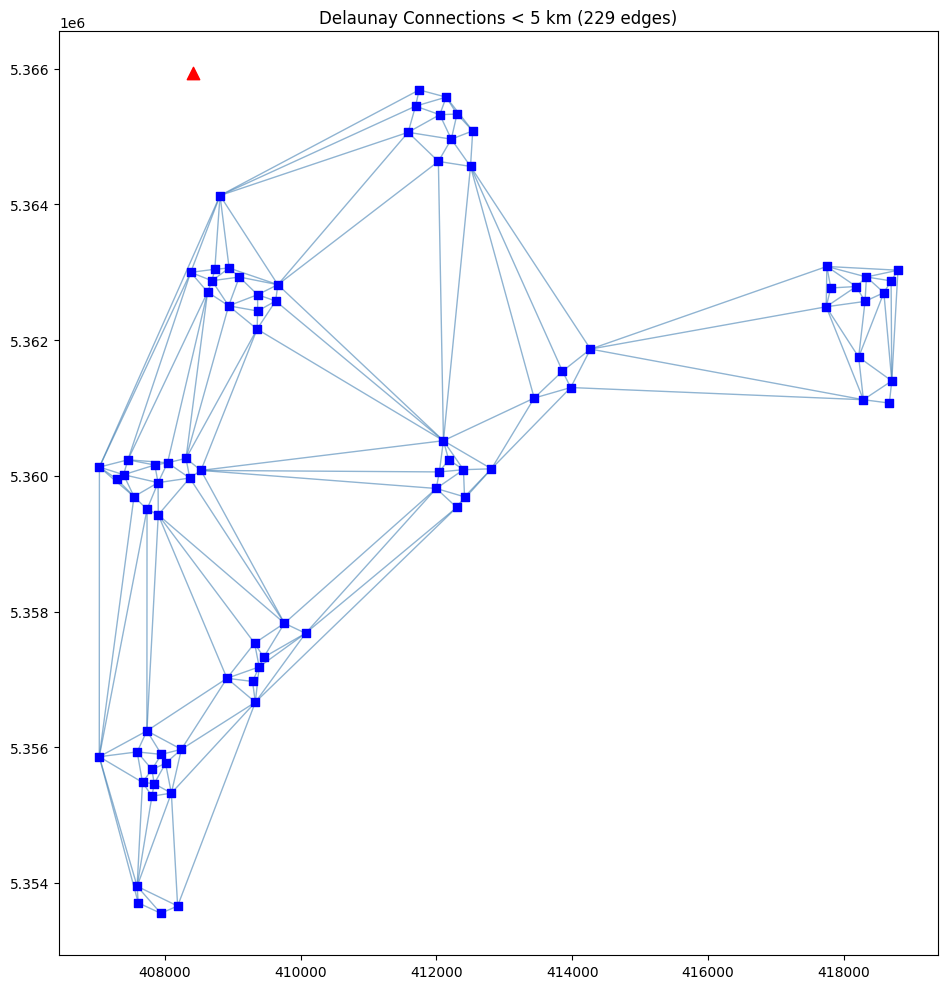

In [22]:
# Visualize filtered Delaunay connections
fig, ax = plt.subplots(figsize=(14, 10))
edge_lines = [LineString([station_geo.loc[fb], station_geo.loc[tb]])
              for fb, tb in filtered_connections]
gpd.GeoSeries(edge_lines, crs=gis_crs).plot(ax=ax, color='steelblue', linewidth=1, alpha=0.6)
station_geo.plot(ax=ax, color='blue', markersize=30, marker='s', zorder=4)
ext_grid_geo.plot(ax=ax, color='red', markersize=80, marker='^', zorder=5)
ax.set_title(f"Delaunay Connections < {max_distance/1000:.0f} km ({len(filtered_connections)} edges)")
plt.tight_layout()
plt.show()

## 4.3 Find Optimal Cable Routes with PYORPS

For each Delaunay edge, we find the **terrain-aware optimal route** using PYORPS. This replaces straight-line distance estimates with realistic, routed cable paths.

In [ ]:
# Build source/target coordinate arrays from filtered connections
source_coords = station_geo.loc[[fb for fb, tb in filtered_connections]]
target_coords = station_geo.loc[[tb for fb, tb in filtered_connections]]

print(f"Routing {len(filtered_connections)} connections in a single PathFinder call...")

pf_route = PathFinder(
    dataset_source=raster_path_oberrhein,
    source_coords=source_coords,
    target_coords=target_coords,
    neighborhood_str="r2",
    search_space_buffer_m=1500,
    ignore_max_cost=True,
)
route_collection = pf_route.find_route(pairwise=False)
routes_gdf = pf_route.create_path_geodataframe()

# Add bus IDs for downstream use
routes_gdf['from_bus'] = [fb for fb, tb in filtered_connections]
routes_gdf['to_bus'] = [tb for fb, tb in filtered_connections]

print(f"Routed: {len(routes_gdf)} / {len(filtered_connections)}")
routes_gdf.head()

Routing 229 connections in a single PathFinder call...


C:\Users\mhnn82\Documents\2_python_projects\pyorps\pyorps\graph\path_finder.py:593: UserWarning: 133 position(s) had maximum cost value (65535) and were corrected:
     Orig Coords        Orig Idx     Corr Coords        Corr Idx
  (418221.9, 5361750.3)   [5438, 12692]    ->  (418232.9, 5361740.3)   [5448, 12703]
  (413978.8, 5361302.3)    [5886, 8449]    ->  (413985.8, 5361295.3)    [5893, 8456]
  (418336.9, 5362931.3)   [4257, 12807]    ->  (418342.9, 5362927.3)   [4261, 12813]
  (408092.6, 5355324.3)   [11864, 2563]    ->  (408096.6, 5355330.3)   [11858, 2567]
  (408006.6, 5355763.3)   [11425, 2477]    ->  (408027.6, 5355785.3)   [11403, 2498]
  (411744.7, 5365688.3)    [1500, 6215]    ->  (411737.7, 5365693.3)    [1495, 6208]
  (409094.7, 5362931.3)    [4257, 3565]    ->  (409107.7, 5362944.3)    [4244, 3578]
  (418593.9, 5362700.3)   [4488, 13064]    ->  (418593.9, 5362703.3)   [4485, 13064]
  (418185.9, 5362791.3)   [4397, 12656]    ->  (418192.9, 5362798.3)   [4390, 12663]
  (409

In [ ]:
pf_route.plot_paths()
plt.title("PYORPS Cable Routes (Terrain-Aware)")
plt.tight_layout()
plt.show()

## 4.4 Build a pandapower Network from Routed Cables

We create a new pandapower network where each Delaunay connection is a cable with the **actual routed length** (not straight-line distance).

In [ ]:
net_new = pp.networks.mv_oberrhein(
    scenario='generation', separation_by_sub=True, include_substations=True
)[1]
new_line_type = "NA2XS2Y 1x240 RM/25 12/20 kV"

# Filter out already-existing connections
existing_edges = set(zip(net_new.line.from_bus, net_new.line.to_bus))
existing_edges |= set(zip(net_new.line.to_bus, net_new.line.from_bus))
new_mask = [(int(r['from_bus']), int(r['to_bus'])) not in existing_edges
            for _, r in routes_gdf.iterrows()]
new_routes = routes_gdf.loc[new_mask].copy()
new_routes['length_km'] = new_routes['path_length'] / 1000

# Batch-create lines + switches
new_line_ids = pp.create_lines(
    net_new, from_buses=new_routes['from_bus'].astype(int).values,
    to_buses=new_routes['to_bus'].astype(int).values,
    length_km=new_routes['length_km'].values, std_type=new_line_type, in_service=True,
    name=[f"New: {fb}-{tb}" for fb, tb in
          zip(new_routes['from_bus'].astype(int), new_routes['to_bus'].astype(int))])
pp.create_switches(net_new, buses=new_routes['from_bus'].astype(int).values,
                   elements=new_line_ids, et='l', closed=True)
new_routes['line_idx'] = new_line_ids
new_lines_df = new_routes

pp.runpp(net_new)
print(f"Added {len(new_lines_df)} cables ({new_lines_df['length_km'].sum():.1f} km, "
      f"{new_lines_df['path_cost'].sum():.0f} EUR)")
print(f"Meshed: max loading {net_new.res_line.loading_percent.max():.1f}%, "
      f"V: [{net_new.res_bus.vm_pu.min():.4f}, {net_new.res_bus.vm_pu.max():.4f}]")

## 4.5 Ring Opening at Smallest Current

MV distribution networks typically operate in **radial (open-ring) topology**. When new cables create loops, we need to **open the ring** by opening the switch with the **smallest current flow**.

### Algorithm
```
while network has cycles:
    1. Find all cycles in the network
    2. Identify switches within the cycles
    3. Open the switch carrying the smallest current
    4. Re-run power flow
    5. Record metrics (loading, voltage, losses)
```

This heuristic ensures we remove the least-utilized connection in each loop, preserving the most important power flow paths.

In [ ]:
def open_rings_smallest_current(net, verbose=True):
    """
    Iteratively open network rings by opening the switch with the smallest current.

    Returns a list of dictionaries with metrics at each iteration.
    """
    history = []
    iteration = 0

    # Build NetworkX graph from closed switches
    nxg = create_nxgraph(net, multi=False)

    while True:
        cycles = cycle_basis(nxg)
        if not cycles:
            break

        # Get all nodes in cycles
        all_cycle_nodes = list(set(node for cycle in cycles for node in cycle))

        # Find lines in cycles
        cycle_lines = net.line.loc[
            net.line.from_bus.isin(all_cycle_nodes) &
            net.line.to_bus.isin(all_cycle_nodes)
        ].index.values

        # Find closed switches on these lines
        switches = net.switch.loc[
            net.switch.element.isin(cycle_lines) &
            net.switch.bus.isin(all_cycle_nodes) &
            net.switch.closed &
            (net.switch.et == 'l')
        ]

        if switches.empty:
            break

        # Find switch with smallest current
        switch_currents = net.res_switch.loc[switches.index, 'i_ka']
        min_switch = switch_currents.idxmin()
        opened_line = net.switch.at[min_switch, 'element']
        opened_current = switch_currents[min_switch]

        # Open the switch
        net.switch.at[min_switch, 'closed'] = False
        pp.runpp(net)

        # Record metrics
        history.append({
            'iteration': iteration,
            'switch_opened': min_switch,
            'line_opened': opened_line,
            'opened_current_ka': opened_current,
            'cycles_remaining': len(cycles) - 1,
            'max_loading': net.res_line.loading_percent.max(),
            'min_voltage': net.res_bus.vm_pu.min(),
            'max_voltage': net.res_bus.vm_pu.max(),
            'total_losses_mw': net.res_line.pl_mw.sum(),
        })

        if verbose:
            print(f"  Iter {iteration:2d}: Opened switch {min_switch} "
                  f"(line {opened_line}, I={opened_current:.4f} kA) "
                  f"-> max loading {net.res_line.loading_percent.max():.1f}%, "
                  f"V: [{net.res_bus.vm_pu.min():.4f}, {net.res_bus.vm_pu.max():.4f}] p.u.")

        # Rebuild graph
        nxg = create_nxgraph(net, multi=False)
        iteration += 1

    if verbose:
        print(f"\nRing opening complete after {iteration} iterations. Network is now radial.")

    return pd.DataFrame(history)

# Run ring opening
print("Opening rings at smallest current...")
ring_history = open_rings_smallest_current(net_new)

## 4.6 Evaluate Cost vs. Technical Benefit

Now we compare the **baseline network** (without new cables) against the **optimized network** (with new cables and optimized ring topology).

In [ ]:
# Compare baseline vs. optimized
baseline_net = pp.networks.mv_oberrhein(
    scenario='generation', separation_by_sub=True, include_substations=True
)[1]
pp.runpp(baseline_net)

print("=" * 70)
print("COMPARISON: Baseline vs. Optimized Network")
print("=" * 70)
print(f"{'Metric':<30} {'Baseline':<20} {'Optimized':<20} {'Change':<15}")
print("-" * 70)

metrics = [
    ('Max line loading [%]',
     baseline_net.res_line.loading_percent.max(),
     net_new.res_line.loading_percent.max()),
    ('Min voltage [p.u.]',
     baseline_net.res_bus.vm_pu.min(),
     net_new.res_bus.vm_pu.min()),
    ('Max voltage [p.u.]',
     baseline_net.res_bus.vm_pu.max(),
     net_new.res_bus.vm_pu.max()),
    ('Voltage range [p.u.]',
     baseline_net.res_bus.vm_pu.max() - baseline_net.res_bus.vm_pu.min(),
     net_new.res_bus.vm_pu.max() - net_new.res_bus.vm_pu.min()),
    ('Total losses [kW]',
     baseline_net.res_line.pl_mw.sum() * 1000,
     net_new.res_line.pl_mw.sum() * 1000),
]

for name, base_val, opt_val in metrics:
    change = opt_val - base_val
    pct = (change / base_val * 100) if base_val != 0 else 0
    sign = "+" if change > 0 else ""
    print(f"{name:<30} {base_val:<20.4f} {opt_val:<20.4f} {sign}{change:.4f} ({sign}{pct:.1f}%)")

print(f"\nNew infrastructure cost: {new_lines_df['cost'].sum():.0f} EUR")
print(f"New cable length:        {new_lines_df['length_km'].sum():.1f} km")

In [ ]:
if len(ring_history) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(ring_history['iteration'], ring_history['max_loading'], 'b-o', ms=4)
    axes[0].axhline(y=baseline_net.res_line.loading_percent.max(), color='r', ls='--', label='Baseline')
    axes[0].set(xlabel="Iteration", ylabel="Max Loading [%]", title="Line Loading")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].fill_between(ring_history['iteration'], ring_history['min_voltage'],
                          ring_history['max_voltage'], alpha=0.3)
    axes[1].axhline(y=0.95, color='grey', ls=':'); axes[1].axhline(y=1.05, color='grey', ls=':')
    axes[1].set(xlabel="Iteration", ylabel="Voltage [p.u.]", title="Voltage Band")
    axes[1].grid(True, alpha=0.3)
    plt.suptitle("Ring Opening Progress")
    plt.tight_layout()
    plt.show()

In [ ]:
# Per-cable cost-benefit analysis
line_ids = new_lines_df['line_idx'].values
sw_mask = net_new.switch.element.isin(line_ids) & (net_new.switch.et == 'l')
sw_status = net_new.switch.loc[sw_mask].set_index('element')['closed']

analysis = new_lines_df[['from_bus', 'to_bus', 'length_km', 'path_cost']].copy()
analysis.columns = ['From', 'To', 'Length [km]', 'Cost [EUR]']
analysis['Active'] = [sw_status.get(new_lines_df.at[i, 'line_idx'], False) for i in analysis.index]

active_cost = analysis.loc[analysis['Active'], 'Cost [EUR]'].sum()
total_cost = analysis['Cost [EUR]'].sum()
print(f"Active cables: {analysis['Active'].sum()} | "
      f"Opened during ring opening: {(~analysis['Active']).sum()}")
print(f"Active cable cost: {active_cost:.0f} EUR | Total: {total_cost:.0f} EUR | "
      f"Savings: {total_cost - active_cost:.0f} EUR")

---
# Part 5: Summary & Next Steps

## What We Learned

| Topic | Key Takeaway |
|-------|-------------|
| **PYORPS fundamentals** | Raster-based least-cost path analysis with configurable neighborhoods (R0&ndash;R3) |
| **Cost raster creation** | Build multi-layer cost rasters from open WFS geodata (land use, protection zones, soil) |
| **Cost assumptions** | Land-use categories mapped to construction costs; 65535 = forbidden |
| **PCC optimization** | Combine PYORPS routing with power flow analysis for technically valid, cost-optimal connections |
| **Grid extension** | Delaunay triangulation + PYORPS + ring opening = automated meshed-to-radial planning |
| **Routing accuracy** | R2 neighborhood offers excellent accuracy with moderate computation |
| **Cost vs. straight-line** | Routed paths are typically 1.1&ndash;1.5x longer than straight-line estimates |

## Advanced Features (Not Covered Today)

- **3D routing** with Digital Elevation Models (DEM)
- **Constrained routing** with turn angles and tower placement (overhead lines)
- **GPU acceleration** for large-scale problems
- **Custom preprocessing** for refined terrain classification (road buffers, soil conditions)

## Resources

- **GitHub**: [github.com/mhnn82/pyorps](https://github.com/mhnn82/pyorps)
- **Documentation**: [pyorps.readthedocs.io](https://pyorps.readthedocs.io)
- **Publication**: *PYORPS: an open-source tool for automated power line routing* (CIRED 2025)

## Contact

**Martin Hofmann M.Sc.**
martin.hofmann-3@ei.thm.de
THM &mdash; University of Applied Sciences, Giessen, Germany

---
*This tutorial notebook was created for the 4th International Workshop on Open Source Modelling and Simulation of Energy Systems (OSMSES 2026), Karlsruhe, Germany.*